# Breast Cancer Diagnosis — MLflow Experiment Tracking

**Goal:** Build a binary classifier that predicts whether a breast tumour is malignant or benign.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features derived
from digitised images of fine needle aspirate (FNA) biopsies.

**What this notebook covers:**
- Manual experiment tracking (params, metrics, artifacts, tags)
- Autologging as a faster alternative
- Hyperparameter sweep with nested runs for clean organisation
- Model Registry: registering, staging, and promoting models
- Loading the Production model for inference
- REST serving setup and payload validation
- Custom PyFunc wrapper with enriched output
- Programmatic run comparison with MlflowClient

**Before running:** Start the MLflow tracking server in a terminal:
```
mlflow server --host 127.0.0.1 --port 5000
```
Then open http://127.0.0.1:5000 to watch runs appear as you execute cells.

## Imports & Configuration

In [11]:
import json
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

import mlflow
import mlflow.sklearn
import mlflow.pyfunc
from mlflow.models.signature import infer_signature
from mlflow.models import validate_serving_input
from mlflow.tracking import MlflowClient

# Add src/ to path so we can import utils
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
sys.path.append('../src')
from utils import compute_metrics, save_confusion_matrix, save_classification_report, build_pipeline

print(f"MLflow {mlflow.__version__} ready")

MLflow 3.10.0 ready


In [12]:
# ---------------------------------------------------------------------------
# Project-wide constants
# All the strings and numbers stays here so changing one thing
# doesn't require hunting through the whole notebook.
# ---------------------------------------------------------------------------

TRACKING_URI     = "http://127.0.0.1:5000"
EXPERIMENT_NAME  = "breast-cancer-diagnosis"
MODEL_NAME       = "breast-cancer-classifier"   # name in the MLflow Model Registry
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
ARTIFACT_DIR     = "/tmp/bc_artifacts"          # local scratch dir for plots/reports

os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Point MLflow at the local server and create the experiment if it doesn't exist.
# In a team setting TRACKING_URI would point at a shared server (Postgres + S3).
mlflow.set_tracking_uri(TRACKING_URI)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment : {EXPERIMENT_NAME}")
print(f"ID         : {experiment.experiment_id}")
print(f"Artifacts  : {ARTIFACT_DIR}")

Experiment : breast-cancer-diagnosis
ID         : 1
Artifacts  : /tmp/bc_artifacts


## 1. Data Loading & Exploration

The Breast Cancer Wisconsin dataset contains measurements computed from digitised images
of breast mass FNA biopsies. Each sample has 30 features — mean, standard error, and
worst (largest) value of 10 nucleus properties like radius, texture, and concavity.

Target: **0 = Malignant**, **1 = Benign**

In [13]:
bc = datasets.load_breast_cancer()
X  = pd.DataFrame(bc.data, columns=bc.feature_names)
y  = pd.Series(bc.target, name="diagnosis")  # 0 = Malignant, 1 = Benign

print(f"Samples  : {X.shape[0]}")
print(f"Features : {X.shape[1]}")
print(f"Classes  : {dict(enumerate(bc.target_names))}")
print(f"\nClass balance:")
print(y.value_counts().rename({0: 'Malignant', 1: 'Benign'}).to_string())

Samples  : 569
Features : 30
Classes  : {0: np.str_('malignant'), 1: np.str_('benign')}

Class balance:
diagnosis
Benign       357
Malignant    212


In [14]:
# Quick look at the feature ranges — they vary massively (area vs smoothness),
# which is why StandardScaler is non-negotiable here.
X.describe().T[["mean", "std", "min", "max"]].style.background_gradient(cmap="Blues", subset=["std"])

,mean,std,min,max
mean radius,14.127292,3.524049,6.981000,28.110000
mean texture,19.289649,4.301036,9.710000,39.280000
mean perimeter,91.969033,24.298981,43.790000,188.500000
mean area,654.889104,351.914129,143.500000,2501.000000
mean smoothness,0.096360,0.014064,0.052630,0.163400
mean compactness,0.104341,0.052813,0.019380,0.345400
mean concavity,0.088799,0.079720,0.000000,0.426800
mean concave points,0.048919,0.038803,0.000000,0.201200
mean symmetry,0.181162,0.027414,0.106000,0.304000
mean fractal dimension,0.062798,0.007060,0.049960,0.097440


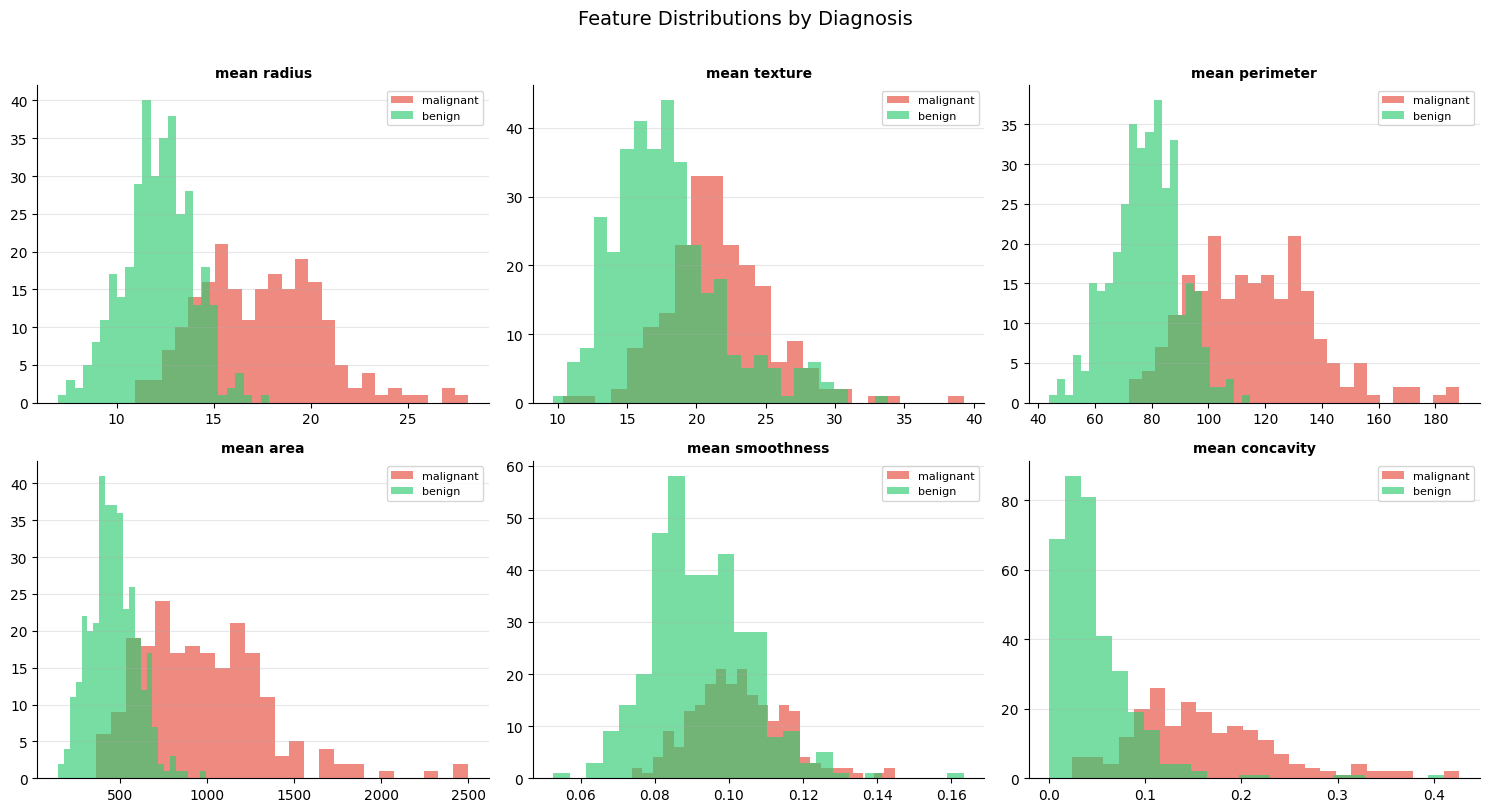

Saved → /tmp/bc_artifacts/feature_distributions.png


In [15]:
# Distribution of the 6 most diagnostically useful features, split by diagnosis.
# Malignant tumours tend to be larger (radius, area) and more irregular (concavity).

top_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness", "mean concavity"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ["#e74c3c", "#2ecc71"]  # red = malignant, green = benign

for ax, feat in zip(axes, top_features):
    for label, color in zip([0, 1], colors):
        ax.hist(
            X.loc[y == label, feat],
            bins=25, alpha=0.65,
            label=bc.target_names[label],
            color=color, edgecolor="none"
        )
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Feature Distributions by Diagnosis", fontsize=14, y=1.01)
plt.tight_layout()

eda_plot_path = os.path.join(ARTIFACT_DIR, "feature_distributions.png")
plt.savefig(eda_plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {eda_plot_path}")

In [16]:
# Stratified split keeps the malignant/benign ratio equal in train and test.
# Without stratify=y, random splits can skew the class balance.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train : {X_train.shape[0]} samples  (malignant={sum(y_train==0)}, benign={sum(y_train==1)})")
print(f"Test  : {X_test.shape[0]}  samples  (malignant={sum(y_test==0)},  benign={sum(y_test==1)})")

Train : 455 samples  (malignant=170, benign=285)
Test  : 114  samples  (malignant=42,  benign=72)


## 2. Manual Experiment Tracking

Manual tracking is verbose but gives you total control over what gets recorded.
I start with this before switching to autologging so I actually understand
what autologging is doing for me.

Everything logged here appears in the MLflow UI under the experiment name:
- **Parameters** — hyperparameters, data config
- **Metrics** — accuracy, F1, ROC-AUC, cross-val scores
- **Tags** — free-form labels for filtering runs
- **Artifacts** — files: plots, reports, the model itself

In [17]:
params_lr_baseline = {
    "model"        : "LogisticRegression",
    "C"            : 1.0,
    "solver"       : "lbfgs",
    "max_iter"     : 1000,
    "penalty"      : "l2",
    "scaler"       : "StandardScaler",
    "random_state" : RANDOM_STATE,
    "test_size"    : TEST_SIZE,
}

with mlflow.start_run(run_name="baseline — logistic regression") as run:

    # --- Train -----------------------------------------------------------
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            C=1.0, solver="lbfgs",
            max_iter=1000, random_state=RANDOM_STATE
        ))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]  # probability of Benign (class 1)

    # --- Log parameters --------------------------------------------------
    # log_params() accepts a dict; use log_param() for a single key-value pair
    mlflow.log_params(params_lr_baseline)

    # --- Log metrics -----------------------------------------------------
    metrics = compute_metrics(y_test, y_pred, y_prob)
    mlflow.log_metrics(metrics)

    # Log cross-val scores as step metrics so they show as a line chart in the UI
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")
    for fold, score in enumerate(cv_scores):
        mlflow.log_metric("cv_roc_auc_fold", score, step=fold)
    mlflow.log_metric("cv_roc_auc_mean", float(cv_scores.mean()))
    mlflow.log_metric("cv_roc_auc_std",  float(cv_scores.std()))

    # --- Tags ------------------------------------------------------------
    # Tags are free-form strings — useful for filtering in the UI
    mlflow.set_tag("tracking_method", "manual")
    mlflow.set_tag("dataset",         "breast_cancer_wisconsin")
    mlflow.set_tag("stage",           "baseline")

    # --- Artifacts -------------------------------------------------------
    # Any file can be logged. artifact_path sets the folder inside the run.

    # Correlation heatmap
    corr_path = os.path.join(ARTIFACT_DIR, "corr_matrix.png")
    plt.figure(figsize=(10, 8))
    sns.heatmap(X.corr(), cmap="coolwarm")
    plt.tight_layout()
    plt.savefig(corr_path)
    plt.close()

    # EDA plots (dataset-level, but useful to have attached to the baseline run)
    mlflow.log_artifact(eda_plot_path,  artifact_path="eda")
    mlflow.log_artifact(corr_path,      artifact_path="eda")

    # Confusion matrix
    cm_path = save_confusion_matrix(y_test, y_pred, "baseline-lr", bc.target_names, ARTIFACT_DIR)
    mlflow.log_artifact(cm_path, artifact_path="plots")

    # Classification report
    report_path = save_classification_report(y_test, y_pred, bc.target_names, ARTIFACT_DIR, prefix="baseline-lr")
    mlflow.log_artifact(report_path, artifact_path="reports")

    # --- Model -----------------------------------------------------------
    # infer_signature() inspects the training data and predictions to record
    # the expected input/output schema — important for the serving endpoint.
    signature = infer_signature(X_train, pipe.predict(X_train))

    model_info = mlflow.sklearn.log_model(
        sk_model              = pipe,
        name                  = "model",
        registered_model_name = MODEL_NAME,   # registers in the Model Registry
        signature             = signature,
        input_example         = X_test.iloc[:3],
    )

    baseline_run_id = run.info.run_id

print(f"Run ID  : {baseline_run_id}")
print(f"Metrics :")
for k, v in metrics.items():
    print(f"  {k:<12}: {v:.4f}")

2026/03/02 15:02:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'breast-cancer-classifier'.
2026/03/02 15:02:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: breast-cancer-classifier, version 1


🏃 View run baseline — logistic regression at: http://127.0.0.1:5000/#/experiments/1/runs/aaec6aa24c4048c6b4696e58affa9295
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run ID  : aaec6aa24c4048c6b4696e58affa9295
Metrics :
  accuracy    : 0.9825
  f1          : 0.9861
  precision   : 0.9861
  recall      : 0.9861
  roc_auc     : 0.9954


Created version '1' of model 'breast-cancer-classifier'.


## 3. Autologging

`mlflow.sklearn.autolog()` instruments sklearn under the hood — every call to `.fit()` 
inside an active run automatically records all of the above without any explicit log calls.

I use autologging during fast exploratory work and switch back to manual tracking
when I need custom metrics (like per-fold CV scores logged as step metrics)
or when I want to log domain-specific artifacts.

In [18]:
# Enable autologging before the run block.
# log_input_examples=True saves a sample of training data alongside the model.
mlflow.sklearn.autolog(
    log_input_examples   = True,
    log_model_signatures = True,
    log_models           = True,
    silent               = False,
)

with mlflow.start_run(run_name="autolog — random forest") as run:

    # Just train. MLflow intercepts the .fit() call and logs everything.
    rf_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=RANDOM_STATE
        ))
    ])
    rf_pipe.fit(X_train, y_train)

    # Can still add tags on top of autologging
    mlflow.set_tag("tracking_method", "autolog")
    mlflow.set_tag("dataset",         "breast_cancer_wisconsin")

    autolog_run_id = run.info.run_id

# Always disable after the run so it doesn't interfere with later cells
mlflow.sklearn.autolog(disable=True)

y_pred_rf = rf_pipe.predict(X_test)
print(f"Run ID        : {autolog_run_id}")
print(f"Test accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nCheck the MLflow UI — params and metrics were captured automatically.")

2026/03/02 15:11:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run autolog — random forest at: http://127.0.0.1:5000/#/experiments/1/runs/e53e607484384585aae3d0c94bb48d37
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run ID        : e53e607484384585aae3d0c94bb48d37
Test accuracy : 0.9561

Check the MLflow UI — params and metrics were captured automatically.


## 4. Hyperparameter Sweep with Nested Runs

Nested runs are the right pattern for hyperparameter search — one parent run
represents the whole sweep, each child run is one trial. The MLflow UI shows
them as a tree so you can collapse/expand the sweep and spot the best trial immediately.

I'm doing a manual grid here, but the same nested-run pattern works identically
with Optuna, Ray Tune, or any other tuning library.

In [19]:
# The search space: 3 model families, varying their most impactful parameters.
# Keeping it to 10 trials so the notebook runs quickly.

param_grid = [
    # Logistic Regression — sweep regularisation strength C
    {"model": "LogisticRegression", "C": 0.01, "solver": "lbfgs"},
    {"model": "LogisticRegression", "C": 0.1,  "solver": "lbfgs"},
    {"model": "LogisticRegression", "C": 1.0,  "solver": "lbfgs"},
    {"model": "LogisticRegression", "C": 10.0, "solver": "lbfgs"},
    # Random Forest — sweep depth and number of trees
    {"model": "RandomForest",       "n_estimators": 50,  "max_depth": 3},
    {"model": "RandomForest",       "n_estimators": 100, "max_depth": 5},
    {"model": "RandomForest",       "n_estimators": 200, "max_depth": 10},
    # Gradient Boosting — sweep learning rate and trees
    {"model": "GradientBoosting",   "n_estimators": 50,  "learning_rate": 0.1},
    {"model": "GradientBoosting",   "n_estimators": 100, "learning_rate": 0.05},
    {"model": "GradientBoosting",   "n_estimators": 100, "learning_rate": 0.2},
]

print(f"{len(param_grid)} trials planned across 3 model families")

10 trials planned across 3 model families


In [20]:
best_roc_auc = 0.0
best_run_id  = None
best_params  = None
best_pipe    = None

# ------------------------------------------------------------------
# PARENT RUN — wraps the entire sweep
# Logging the best result to the parent makes it visible at a glance
# in the UI without having to drill into children.
# ------------------------------------------------------------------
with mlflow.start_run(run_name="sweep — parent") as parent_run:

    mlflow.set_tag("run_type",       "hyperparameter_sweep")
    mlflow.set_tag("dataset",        "breast_cancer_wisconsin")
    mlflow.log_param("n_trials",     len(param_grid))
    mlflow.log_param("search_method","grid")

    for i, params in enumerate(param_grid):
        trial_name = f"trial-{i+1:02d} {params['model'].lower()}"

        # --------------------------------------------------------------
        # CHILD RUN — one trial
        # nested=True links it to the parent run in the UI
        # --------------------------------------------------------------
        with mlflow.start_run(run_name=trial_name, nested=True) as child_run:

            pipe    = build_pipeline(params, random_state=RANDOM_STATE)
            pipe.fit(X_train, y_train)

            y_pred  = pipe.predict(X_test)
            y_prob  = pipe.predict_proba(X_test)[:, 1]
            metrics = compute_metrics(y_test, y_pred, y_prob)

            mlflow.log_params(params)
            mlflow.log_param("random_state", RANDOM_STATE)
            mlflow.log_metrics(metrics)
            mlflow.set_tag("run_type", "child_trial")
            mlflow.set_tag("dataset",  "breast_cancer_wisconsin")

            # Track the best child
            if metrics["roc_auc"] > best_roc_auc:
                best_roc_auc = metrics["roc_auc"]
                best_run_id  = child_run.info.run_id
                best_params  = params.copy()
                best_pipe    = pipe

            print(f"  [{i+1:02d}] {params['model']:<20} "
                  f"ROC-AUC={metrics['roc_auc']:.4f}  "
                  f"Acc={metrics['accuracy']:.4f}")

    # Write the sweep summary back to the parent run
    mlflow.log_metric("best_roc_auc", best_roc_auc)
    mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
    mlflow.set_tag("best_child_run_id", best_run_id)

    sweep_parent_id = parent_run.info.run_id

print(f"\nBest ROC-AUC : {best_roc_auc:.4f}")
print(f"Best model   : {best_params}")
print(f"Best run ID  : {best_run_id}")

  [01] LogisticRegression   ROC-AUC=0.9950  Acc=0.9474
🏃 View run trial-01 logisticregression at: http://127.0.0.1:5000/#/experiments/1/runs/97d9bcf6449e413c9e395b374e741915
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  [02] LogisticRegression   ROC-AUC=0.9957  Acc=0.9737
🏃 View run trial-02 logisticregression at: http://127.0.0.1:5000/#/experiments/1/runs/ef7540da8b0048358c4194018e79845b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  [03] LogisticRegression   ROC-AUC=0.9954  Acc=0.9825
🏃 View run trial-03 logisticregression at: http://127.0.0.1:5000/#/experiments/1/runs/7d9f4e129c544496ae1a87579328fc2d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  [04] LogisticRegression   ROC-AUC=0.9934  Acc=0.9649
🏃 View run trial-04 logisticregression at: http://127.0.0.1:5000/#/experiments/1/runs/919cca812eae43dc839442a5bd22de36
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  [05] RandomForest         ROC-AUC=0.9904  Acc=0.9474
🏃 View ru

## 5. Model Registry — Register & Promote

The Model Registry is MLflow's versioned store for production models.
The lifecycle stages are:

```
None → Staging → Production → Archived
```

Loading by stage (`models:/name/Production`) rather than version number means
application code never needs to change when a new model is promoted — you just
move the version in the registry.

In [21]:
client = MlflowClient(tracking_uri=TRACKING_URI)

# Register the best pipeline from the sweep.
# The baseline LR was already registered in Section 2 — this adds a new version.
with mlflow.start_run(run_name="register best model from sweep") as run:

    signature = infer_signature(X_train, best_pipe.predict(X_train))

    model_info = mlflow.sklearn.log_model(
        sk_model              = best_pipe,
        name                  = "model",
        registered_model_name = MODEL_NAME,
        signature             = signature,
        input_example         = X_test.iloc[:5],
    )

    mlflow.log_params(best_params)
    mlflow.log_metric("roc_auc", best_roc_auc)
    mlflow.set_tag("note", "best model from hyperparameter sweep")

    registered_version = model_info.registered_model_version

print(f"Registered '{MODEL_NAME}' version {registered_version}")

2026/03/02 15:25:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'breast-cancer-classifier' already exists. Creating a new version of this model...
2026/03/02 15:25:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: breast-cancer-classifier, version 2


🏃 View run register best model from sweep at: http://127.0.0.1:5000/#/experiments/1/runs/6804cb3085dc40f89313948639eefc3b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Registered 'breast-cancer-classifier' version 2


Created version '2' of model 'breast-cancer-classifier'.


In [22]:
# Walk the best model through the lifecycle.
# In practice Staging → Production would be gated by evaluation tests
# or a team review, not done immediately like this.

ver = str(registered_version)

# Step 1: Staging — model is deployed to a test environment
client.transition_model_version_stage(
    name    = MODEL_NAME,
    version = ver,
    stage   = "Staging",
    archive_existing_versions=False
)
print(f"Version {ver} → Staging")

# Step 2: Production — model is live; older Production versions get archived
client.transition_model_version_stage(
    name    = MODEL_NAME,
    version = ver,
    stage   = "Production",
    archive_existing_versions=True  # automatically archives the previous Production
)
print(f"Version {ver} → Production")

# Add human-readable metadata
client.update_model_version(
    name        = MODEL_NAME,
    version     = ver,
    description = (
        f"Best model from hyperparameter sweep. "
        f"ROC-AUC={best_roc_auc:.4f}. "
        f"Params: {best_params}"
    )
)
client.update_registered_model(
    name        = MODEL_NAME,
    description = (
        "Breast cancer malignancy classifier. "
        "Input: 30 FNA biopsy measurements. "
        "Output: 0 = Malignant, 1 = Benign."
    )
)

print(f"\nAll versions of '{MODEL_NAME}':")
for mv in client.search_model_versions(f"name='{MODEL_NAME}'"):
    print(f"  v{mv.version:<3} {mv.current_stage:<12} run={mv.run_id[:10]}...")

Version 2 → Staging
Version 2 → Production

All versions of 'breast-cancer-classifier':
  v2   Production   run=6804cb3085...
  v1   None         run=aaec6aa24c...


## 6. Loading from the Registry & Running Inference

Two loading options:
- `mlflow.pyfunc.load_model()` — generic, works for any MLflow model flavour, returns a pyfunc wrapper
- `mlflow.sklearn.load_model()` — sklearn-specific, gives back the actual Pipeline object
  so you can call `.predict_proba()` etc. directly

In [23]:
# Loading by stage name means this cell always loads whatever is currently
# in Production without any code changes.
prod_uri = f"models:/{MODEL_NAME}/Production"

# pyfunc — generic, recommended for serving
prod_pyfunc  = mlflow.pyfunc.load_model(prod_uri)

# sklearn — lets you access pipeline internals (predict_proba, named_steps, etc.)
prod_sklearn = mlflow.sklearn.load_model(prod_uri)

print(f"Loaded from: {prod_uri}")

# Predict
preds        = prod_pyfunc.predict(X_test)
y_prob_prod  = prod_sklearn.predict_proba(X_test)[:, 1]

print(f"Accuracy    : {accuracy_score(y_test, preds):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_prob_prod):.4f}")

Loaded from: models:/breast-cancer-classifier/Production
Accuracy    : 0.9737
ROC-AUC     : 0.9957


In [24]:
# Build a results DataFrame to inspect individual predictions
results = X_test[top_features].copy()
results["actual"]      = [bc.target_names[c] for c in y_test.values]
results["predicted"]   = [bc.target_names[c] for c in preds]
results["prob_benign"] = y_prob_prod.round(4)
results["correct"]     = results["actual"] == results["predicted"]

n_correct = results["correct"].sum()
n_total   = len(results)
print(f"Correct predictions : {n_correct} / {n_total}  ({n_correct/n_total:.1%})")
print(f"Misclassified       : {n_total - n_correct}")

# Highlight misclassified rows
results.head(15).style.apply(
    lambda row: ["background-color: #ffe0e0" if not row["correct"] else "" for _ in row],
    axis=1
)

Correct predictions : 111 / 114  (97.4%)
Misclassified       : 3


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity,actual,predicted,prob_benign,correct
256,19.550000,28.770000,133.600000,1207.000000,0.092600,0.178400,malignant,malignant,0.000000,True
428,11.130000,16.620000,70.470000,381.100000,0.081510,0.013690,benign,benign,0.999300,True
501,13.820000,24.490000,92.330000,595.900000,0.116200,0.135700,malignant,malignant,0.051200,True
363,16.500000,18.290000,106.600000,838.100000,0.096860,0.058620,benign,benign,0.569700,True
564,21.560000,22.390000,142.000000,1479.000000,0.111000,0.243900,malignant,malignant,0.000000,True
464,13.170000,18.220000,84.280000,537.300000,0.074660,0.048590,benign,benign,0.966400,True
358,8.878000,15.490000,56.740000,241.000000,0.082930,0.047210,benign,benign,0.999100,True
343,19.680000,21.680000,129.900000,1194.000000,0.097970,0.186300,malignant,malignant,0.000300,True
516,18.310000,20.580000,120.800000,1052.000000,0.106800,0.156900,malignant,malignant,0.005000,True
567,20.600000,29.330000,140.100000,1265.000000,0.117800,0.351400,malignant,malignant,0.000000,True


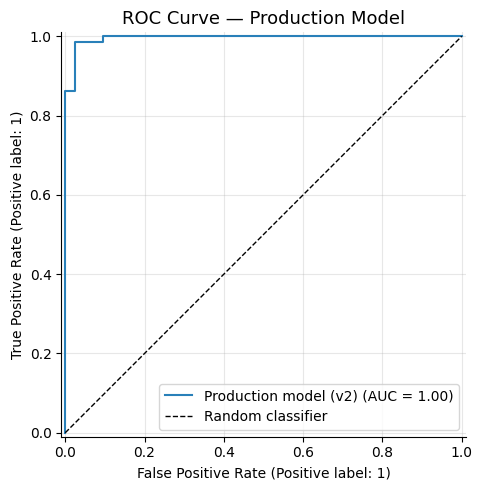

🏃 View run trial-02 logisticregression at: http://127.0.0.1:5000/#/experiments/1/runs/ef7540da8b0048358c4194018e79845b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [25]:
# ROC curve for the Production model
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_prod,
    name=f"Production model (v{ver})",
    ax=ax, color="#2980b9"
)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_title("ROC Curve — Production Model", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

roc_path = os.path.join(ARTIFACT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=120)
plt.show()

# Log the ROC curve back to the best child run as a reference artifact
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(roc_path, artifact_path="plots")

## 7. REST Serving

MLflow can serve any registered model as a REST API with a single terminal command.
The endpoint accepts JSON and returns predictions — same interface regardless of
what framework trained the model.

Start the server in a separate terminal:
```bash
mlflow models serve \
  --model-uri "models:/breast-cancer-classifier/Production" \
  --port 5001 \
  --no-conda
```

Two endpoints are exposed:
- `GET  /ping`         — health check
- `POST /invocations`  — prediction (accepts `dataframe_split` or `instances` JSON format)

In [26]:
# Build the JSON payload that you'd POST to /invocations.
# dataframe_split is the most explicit format: separate columns and data arrays.

sample = X_test.head(5)
split  = sample.to_dict(orient="split")
split.pop("index", None)  # index field is not needed by the server

serving_payload = json.dumps({"dataframe_split": split})

# Quick sanity check — first 500 chars
print(json.dumps(json.loads(serving_payload), indent=2)[:500])
print("...")

{
  "dataframe_split": {
    "columns": [
      "mean radius",
      "mean texture",
      "mean perimeter",
      "mean area",
      "mean smoothness",
      "mean compactness",
      "mean concavity",
      "mean concave points",
      "mean symmetry",
      "mean fractal dimension",
      "radius error",
      "texture error",
      "perimeter error",
      "area error",
      "smoothness error",
      "compactness error",
      "concavity error",
      "concave points error",
      "symmetry
...


In [27]:
# validate_serving_input() runs the payload through the model locally,
# simulating what the REST endpoint would do — no server required.
# Catches schema mismatches before deployment.

try:
    result = validate_serving_input(prod_uri, serving_payload)
    labels = [bc.target_names[p] for p in result]
    print("Serving validation passed")
    print(f"Predicted : {labels}")
except Exception as e:
    print(f"Validation error: {e}")

Serving validation passed
Predicted : [np.str_('malignant'), np.str_('benign'), np.str_('malignant'), np.str_('benign'), np.str_('malignant')]


In [30]:
import requests

# Health check
resp = requests.get("http://127.0.0.1:6001/ping")
print("Ping:", resp.status_code, resp.text)

# Prediction
resp = requests.post(
    "http://127.0.0.1:6001/invocations",   # <-- changed 5001 -> 6001
    headers={"Content-Type": "application/json"},
    data=serving_payload,
)
print("Status :", resp.status_code)
print("Result :", resp.json())

print("Uncomment the block above after starting the serving server.")
print(f"Command: mlflow models serve --model-uri '{prod_uri}' --port 6001 --no-conda")

Ping: 200 

Status : 200
Result : {'predictions': [0, 1, 0, 1, 0]}
Uncomment the block above after starting the serving server.
Command: mlflow models serve --model-uri 'models:/breast-cancer-classifier/Production' --port 6001 --no-conda


## 8. Custom PyFunc Model

`mlflow.pyfunc.PythonModel` lets you wrap any Python object — not just sklearn —
in MLflow's standard interface. The key method is `predict()`, which receives
a pandas DataFrame and can return anything serialisable.

I'm using it here to return enriched output (diagnosis label, confidence score,
clinical risk level) rather than just a raw class integer — something a downstream
app or dashboard could use directly.

In [33]:
class DiagnosisModel(mlflow.pyfunc.PythonModel):
    """
    MLflow PyFunc wrapper around a sklearn Pipeline.

    Returns a DataFrame with enriched prediction columns instead of
    the raw integer class labels that a plain sklearn model returns.
    """

    def __init__(self, pipeline, class_names):
        self.pipeline    = pipeline
        self.class_names = class_names  # e.g. ['malignant', 'benign']

    def predict(self, context, model_input):
        # Normalise input — accept both DataFrames and numpy arrays
        if not isinstance(model_input, pd.DataFrame):
            model_input = pd.DataFrame(model_input)

        preds  = self.pipeline.predict(model_input)          # [0, 1, 1, ...]
        probas = self.pipeline.predict_proba(model_input)    # [[p0, p1], ...]

        # Confidence = probability assigned to the predicted class
        confidence    = probas[np.arange(len(preds)), preds]

        # Malignancy probability drives the risk level
        prob_malignant = probas[:, 0]
        risk_level = np.where(
            prob_malignant > 0.70, "High",
            np.where(prob_malignant > 0.30, "Medium", "Low")
        )

        return pd.DataFrame({
            "predicted_class"  : preds,
            "diagnosis"        : [self.class_names[p] for p in preds],
            "confidence"       : confidence.round(4),
            "prob_malignant"   : prob_malignant.round(4),
            "risk_level"       : risk_level,
        })


print("DiagnosisModel class defined")

DiagnosisModel class defined


/Users/sykambharath/Library/Caches/pypoetry/virtualenvs/breat-cancer-mlflow-RkeACokP-py3.11/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [34]:
diagnosis_model = DiagnosisModel(
    pipeline    = best_pipe,
    class_names = list(bc.target_names)
)

with mlflow.start_run(run_name="pyfunc — enriched diagnosis model") as run:

    mlflow.set_tag("model_type",    "custom_pyfunc")
    mlflow.set_tag("output_format", "enriched_dataframe")
    mlflow.set_tag("dataset",       "breast_cancer_wisconsin")

    # Build the signature from a sample output so MLflow knows the output schema
    sample_output = diagnosis_model.predict(None, X_test.iloc[:3])
    signature     = infer_signature(
        model_input  = X_train,
        model_output = sample_output
    )

    pyfunc_info = mlflow.pyfunc.log_model(
        python_model  = diagnosis_model,
        name          = "diagnosis_model",
        signature     = signature,
        input_example = X_test.iloc[:3],
    )

    pyfunc_run_id = run.info.run_id

print(f"PyFunc model logged. Run ID: {pyfunc_run_id}")

2026/03/02 17:37:52 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/03/02 17:37:52 INFO mlflow.pyfunc: Validating input example against model signature


🏃 View run pyfunc — enriched diagnosis model at: http://127.0.0.1:5000/#/experiments/1/runs/f92a748e9e50456499fba27ded478e27
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
PyFunc model logged. Run ID: f92a748e9e50456499fba27ded478e27


## 9. Programmatic Run Comparison

`mlflow.search_runs()` returns a DataFrame of all runs matching a filter,
making it easy to compare experiments in code rather than clicking through the UI.
This is what you'd use in a CI/CD step that automatically promotes the best model.

In [38]:
exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

# Fetch only the child trial runs from the sweep — not the parent or baseline
trial_runs = mlflow.search_runs(
    experiment_ids = [exp_id],
    filter_string  = "tags.run_type = 'child_trial'",
    order_by       = ["metrics.roc_auc DESC"]
)

# Keep only the columns worth comparing
keep = [
    "tags.mlflow.runName",
    "params.model", "params.C", "params.n_estimators", "params.learning_rate",
    "metrics.accuracy", "metrics.roc_auc", "metrics.f1",
    "metrics.precision", "metrics.recall",
]
keep = [c for c in keep if c in trial_runs.columns]

comparison = (
    trial_runs[keep]
    .rename(columns={
        "tags.mlflow.runName" : "Run",
        "params.model"        : "Model",
        "metrics.accuracy"    : "Accuracy",
        "metrics.roc_auc"     : "ROC-AUC",
        "metrics.f1"          : "F1",
        "metrics.precision"   : "Precision",
        "metrics.recall"      : "Recall",
    })
    .reset_index(drop=True)
)

print(f"Top results from {len(comparison)} trials:")
comparison.style.highlight_max(
    subset=["Accuracy", "ROC-AUC", "F1"], color= "Blue"
).highlight_min(
    subset=["Accuracy", "ROC-AUC", "F1"], color= "Blue"
)

Top results from 10 trials:


,Run,Model,params.C,params.n_estimators,params.learning_rate,Accuracy,ROC-AUC,F1,Precision,Recall
0,trial-02 logisticregression,LogisticRegression,0.1,None,None,0.973684,0.995701,0.979310,0.972603,0.986111
1,trial-03 logisticregression,LogisticRegression,1.0,None,None,0.982456,0.995370,0.986111,0.986111,0.986111
2,trial-01 logisticregression,LogisticRegression,0.01,None,None,0.947368,0.995040,0.959459,0.934211,0.986111
3,trial-06 randomforest,RandomForest,None,100,None,0.956140,0.993386,0.965517,0.958904,0.972222
4,trial-04 logisticregression,LogisticRegression,10.0,None,None,0.964912,0.993386,0.972222,0.972222,0.972222
5,trial-07 randomforest,RandomForest,None,200,None,0.956140,0.993221,0.965517,0.958904,0.972222
6,trial-10 gradientboosting,GradientBoosting,None,100,0.2,0.956140,0.992394,0.965986,0.946667,0.986111
7,trial-05 randomforest,RandomForest,None,50,None,0.947368,0.990410,0.958333,0.958333,0.958333
8,trial-09 gradientboosting,GradientBoosting,None,100,0.05,0.947368,0.990079,0.958904,0.945946,0.972222
9,trial-08 gradientboosting,GradientBoosting,None,50,0.1,0.947368,0.988426,0.958904,0.945946,0.972222


In [39]:
# Final view of the Model Registry
print(f"Model Registry: '{MODEL_NAME}'")
print("-" * 60)
for mv in client.search_model_versions(f"name='{MODEL_NAME}'"):
    print(f"  v{mv.version:<3}  {mv.current_stage:<12}  run={mv.run_id[:12]}...")
    if mv.description:
        desc = mv.description[:65] + "..." if len(mv.description) > 65 else mv.description
        print(f"        {desc}")

Model Registry: 'breast-cancer-classifier'
------------------------------------------------------------
  v2    Production    run=6804cb3085dc...
        Best model from hyperparameter sweep. ROC-AUC=0.9957. Params: {'m...
  v1    None          run=aaec6aa24c40...


## Summary

| Concept | What I did |
|---------|------------|
| Manual tracking | Logged params, step metrics, artifacts, tags for a baseline LR model |
| Autologging | Single `autolog()` call captured a Random Forest run automatically |
| Nested runs | 10-trial sweep across LR / RF / GBM organised as parent → child tree |
| Model Registry | Registered best model, promoted through Staging → Production |
| Stage-based loading | Loaded Production model by stage name, not version number |
| REST serving | Built and validated serving payload; serving command documented |
| Custom PyFunc | Wrapped pipeline to return diagnosis label, confidence, and risk level |
| Programmatic comparison | Queried runs with `search_runs()` + styled comparison DataFrame |

**Possible next steps:**
- Replace the manual grid with Optuna (Bayesian search, same nested-run pattern)
- Add an `MLproject` file to make `mlflow run .` work reproducibly
- Point `TRACKING_URI` at a PostgreSQL + S3 backend for team use
- Use model aliases (`client.set_registered_model_alias`) instead of stages (MLflow ≥ 2.9)